In [1]:
# import
import seaborn as sns # iris 데이터
import pandas as pd   # 원핫 인코딩
import numpy as np
from sklearn.preprocessing import LabelEncoder # 라벨인코딩(문자->숫자)
from sklearn.model_selection import train_test_split # 데이터 분할
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.models import Sequential, load_model, save_model
from tensorflow.keras.layers import Dense, Dropout, Input, add
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt # 학습과정 시각화


- iris 데이터
1. sepal_length : 꽃받침길이
2. sepal_width : 꽃받침넓이
3. petal_length : 꽃잎길이
4. petal_width : 꽃잎넓이
5. species : 종

In [2]:
# 문자변수의 원핫인코딩
iris = sns.load_dataset('iris')
# iris['species']
labelEncoder = LabelEncoder()
# labelEncoder.fit(iris['species'])
# iris['y'] = labelEncoder.transform(iris['species'])
iris['y'] = labelEncoder.fit_transform(iris.species)
# iris.iloc[::25]
to_categorical(iris['y'])[::25] # to_categorical 의 결과는 numpy 배열

array([[1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.]], dtype=float32)

In [2]:
# 문자변수 원핫인코딩 방법2
iris = sns.load_dataset('iris')
pd.get_dummies(iris['species']).values # pd.get_dummies결과는 데이터프레임
pd.get_dummies(iris['species']).to_numpy()

array([[1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0, 1, 0],
       [0,

In [3]:
# 데이터 생성 및 전처리
iris = sns.load_dataset('iris')
# iris.info() 결측치있으면 결측치 처리
# iris['species'].value_counts() 타겟변수의 분포
# 독립변수와 타겟변ㅅ ㅜ분리
iris_X = iris.iloc[:, :-1].to_numpy()
# iris_X[:2]
iris_y = iris.iloc[:, -1]
iris_Y = pd.get_dummies(iris_y).values
# iris_Y[::50]
# 훈련셋 : 테스트셋 = 8:2
X_train, X_test, Y_train, Y_test = train_test_split(iris_X, iris_Y,
                                                    train_size= 0.8, #훈련셋 비율
                                                    # test_size=0.2, # 테스트비율
                                                    # stratify=iris_Y, # 층화추출
                                                    random_state=7 # 랜덤시드값
                                                    )
print(iris_X.shape, iris_Y.shape)
print(X_train.shape, X_test.shape, Y_train.shape, Y_test.shape)

(150, 4) (150, 3)
(120, 4) (30, 4) (120, 3) (30, 3)


In [4]:
# 층화추출이 되었는지 확인
# iris_Y.argmax(axis=1)
pd.Series(np.argmax(iris_Y, axis=1)).value_counts()

0    50
1    50
2    50
dtype: int64

In [16]:
# 2. 모델구성(입력4, 출력3)
model = Sequential()
model.add(Dense(units=64, input_dim=4, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=50,  activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(units=30,  activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(units=3,  activation='softmax')) # 출력층
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 64)                320       
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_6 (Dense)             (None, 128)               8320      
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_7 (Dense)             (None, 50)                6450      
                                                                 
 dropout_2 (Dropout)         (None, 50)                0         
                                                                 
 dense_8 (Dense)             (None, 30)               

In [17]:
# 3. 학습과정 설정
model.compile(loss='categorical_crossentropy',
              optimizer = 'adam',
              metrics=['accuracy'])
# 4. 학습 : epoch마다 val_accuracy값이 좋아지고 있으면 model 자동저장(콜백추가)
    # 모델 자동 저장될 경로 : ./model10/iris-002-val0.8745.h5
import os
model_save_folder = './model10/'
if not os.path.exists(model_save_folder): # 폴더가 없으면 폴더 생성
    os.mkdir(model_save_folder)
file = model_save_folder + 'iris-{epoch:03d}-val{val_accuracy:.4f}.h5'
# 모델 자동 저장할 콜백 객체
checkpoint = ModelCheckpoint(filepath=file,
                             monitor='val_accuracy', # 모니터링 지표 (기본값: val_loss)
                             mode='max',
                             save_best_only=True, # False : 매번 저장
                             verbose=1 # 모델 저장시 로그 출력 (0:로그출력 X)
                             )
# 조기 종료 콜백 객체
earlyStopping = EarlyStopping(patience=40) # monitor기본값은 val_loss
hist = model.fit(X_train, Y_train,
                #  batch_size=40,
                 epochs=500,
                 validation_split=0.2, # 훈련셋의 20%를 검증셋
                 callbacks=[earlyStopping, checkpoint]
                 )

Epoch 1/500
1/3 [=========>....................] - ETA: 1s - loss: 1.2080 - accuracy: 0.2812
Epoch 1: val_accuracy improved from -inf to 0.37500, saving model to ./model10\iris-001-val0.3750.h5
3/3 [==============================] - 1s 138ms/step - loss: 1.1774 - accuracy: 0.2917 - val_loss: 1.0803 - val_accuracy: 0.3750
Epoch 2/500
1/3 [=========>....................] - ETA: 0s - loss: 1.2348 - accuracy: 0.2188
Epoch 2: val_accuracy improved from 0.37500 to 0.58333, saving model to ./model10\iris-002-val0.5833.h5
3/3 [==============================] - 0s 36ms/step - loss: 1.1457 - accuracy: 0.3646 - val_loss: 1.0587 - val_accuracy: 0.5833
Epoch 3/500
1/3 [=========>....................] - ETA: 0s - loss: 1.1266 - accuracy: 0.3125
Epoch 3: val_accuracy did not improve from 0.58333
3/3 [==============================] - 0s 26ms/step - loss: 1.1257 - accuracy: 0.3229 - val_loss: 1.0335 - val_accuracy: 0.5833
Epoch 4/500
1/3 [=========>....................] - ETA: 0s - loss: 1.0751 - accu

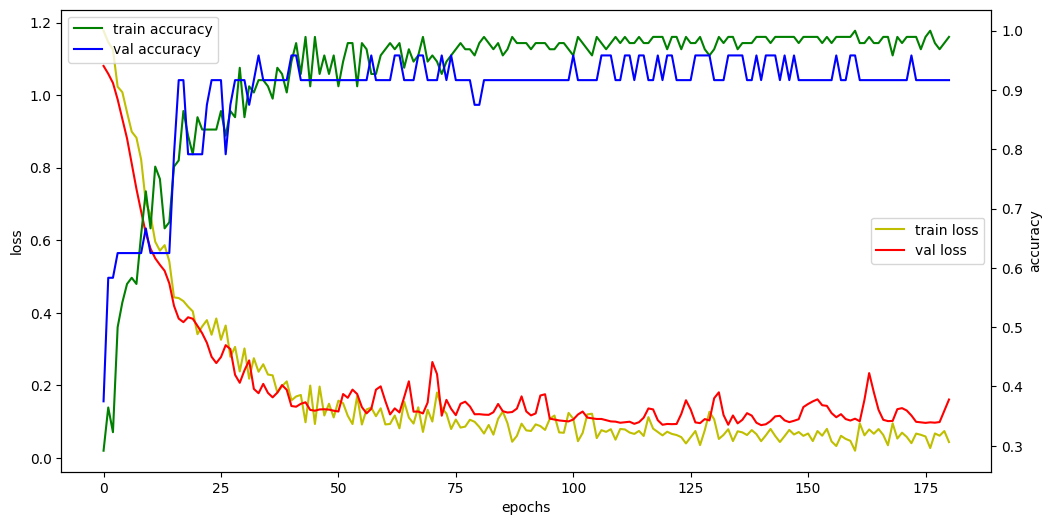

loss : 0.11208587139844894
accuracy : 0.9666666388511658


In [18]:
fig, loss_ax = plt.subplots(figsize=(12, 6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

loss_and_metrics = model.evaluate(X_test, Y_test, batch_size=100, verbose=0)
print('loss :', loss_and_metrics[0])
print('accuracy :', loss_and_metrics[1])

In [29]:
# 6. 모델 평가(evaluate:테스트셋, 교차표,recall,precision:y실제값,y예측값)
# iris-034-val0.9583.h5 모델도 같이 평가
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score, precision_score, f1_score
# 학습된 모델
loss, acc = model.evaluate(X_test, Y_test)
loss, acc 
# 학습완료된 모델의 recall과 precision을 위해서 실제값과 예측값
real = np.argmax(Y_test, axis=1)
pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
recall = recall_score(real, pred, average='weighted') # average='weighted':다중분류
precision = precision_score(real, pred, average='weighted')
f1     = f1_score(real, pred, average='weighted')
print('model loss :', loss)
print('model accuracy :', acc)
print('model recall :', recall)
print('model precision :', precision)
print('model f1 score :', f1)
# 저장된 모델의 평가
model2 = load_model('model10/iris-034-val0.9583.h5')
loss, acc = model2.evaluate(X_test, Y_test)
pred = model2.predict(X_test, verbose=0).argmax(axis=1)
recall = recall_score(real, pred, average='weighted')
precision = precision_score(real, pred, average='weighted')
f1 = f1_score(real, pred, average='weighted')
print('model2 loss :', loss)
print('model2 acc :', acc)
print('model2 recall :', recall)
print('model2 precision :', precision)
print('model2 f1 :', f1)

1/1 [==============================] - 0s 51ms/step - loss: 0.1121 - accuracy: 0.9667
model loss : 0.11208587139844894
model accuracy : 0.9666666388511658
model recall : 0.9666666666666667
model precision : 0.9694444444444444
model f1 score : 0.9666666666666667
1/1 [==============================] - 0s 182ms/step - loss: 0.1883 - accuracy: 0.9667
model2 loss : 0.1883024275302887
model2 acc : 0.9666666388511658
model2 recall : 0.9666666666666667
model2 precision : 0.9694444444444444
model2 f1 : 0.9666666666666667


In [27]:
# 교차표
pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
pd.crosstab(real, pred,
         rownames=['real'], colnames=['pred'])

pred,0,1,2
real,,,
0,7,0,0
1,0,11,1
2,0,0,11


In [28]:
confusion_matrix(real, pred)

array([[ 7,  0,  0],
       [ 0, 11,  1],
       [ 0,  0, 11]], dtype=int64)

In [31]:
# 모델 저장 및 사용
save_model(model, 'model10/iris.h5')
model.save('model10/iris.h5')# tensorflow2.18이상일 경우 확장자를 .keras로도 사용할 수 있음

In [30]:
# 모델 예측하기
# iris.loc[100] (6.3, 3.3, 6.0, 2.5) 예측하기
result = model.predict([[6.3, 3.3, 6.1, 2.5]])
np.argmax(result) # virginica로 예측

1/1 [==============================] - 0s 53ms/step


2